## MLP classification example

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier 
from sklearn.model_selection import train_test_split

iris_df = pd.read_csv("/home/vgv/Documents/AIB2026/episodes/data/iris.csv")
iris_df['labels'] = iris_df.variety.astype('category').cat.codes
X, y = iris_df.iloc[:, :4], iris_df['labels'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)
print(X_train.shape, y_train.shape)
clf = MLPClassifier(solver='lbfgs', random_state=1, max_iter=300)
clf.fit(X, y) 
result = clf.predict(X_test)
ground = np.array(y_test)
print(result, ground)
clf.score(X_test, y_test)

(112, 4) (112,)
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2] [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1]


0.9736842105263158

## MLP Regression example

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
iris_df = pd.read_csv("/home/vgv/Documents/AIB2026/episodes/data/iris.csv")
X, y = iris_df.iloc[:, :3], iris_df["petal.width"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0) 
print(X_train.shape, y_train.shape)
clf = MLPRegressor(solver='lbfgs', random_state=1, max_iter=300)
clf.fit(X, y)
result = clf.predict(X_test)
ground = np.array(y_test)
print(result, ground)
clf.score(X_test, y_test) 

(112, 3) (112,)
[1.94487632 1.18374042 0.27421059 2.03723952 0.24734224 2.32258475
 0.2256798  1.49325046 1.51803665 1.20463722 1.91036986 1.42731483
 1.63076434 1.44756747 1.62095602 0.2320547  1.46672415 1.56325777
 0.22799832 0.25637321 1.93039844 1.58511549 0.37527814 0.19698927
 1.69185532 0.17289891 0.3774613  1.33694044 0.93847957 0.26144152
 2.09534875 1.64921531 0.25985565 1.79742949 1.96606689 1.21215313
 0.321218   1.86435978] [2.4 1.  0.2 1.8 0.2 2.5 0.3 1.5 1.4 1.3 1.4 1.5 1.2 1.5 1.4 0.1 1.5 1.2
 0.3 0.4 2.  1.5 0.2 0.2 1.8 0.2 0.4 1.3 1.  0.4 1.8 1.5 0.2 1.8 2.2 1.4
 0.3 1.6]


/home/vgv/anaconda3/envs/aaib26/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


0.9246017837617708

## NN classification example

In [33]:
import torch
import torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)
print(X_train.shape)
X_tr_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_train, dtype=torch.long)


(120, 4)


In [34]:
class FullyConnected(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(4, 64)  # Input layer to 64 neurons
        self.act1 = nn.ReLU()       # ReLU activation function
        self.l2 = nn.Linear(64, 16) # 64 neurons to 16 neurons
        self.drop = nn.Dropout(0.2) # Dropout for regularization
        self.act2 = nn.ReLU()       # Another ReLU
        self.l3 = nn.Linear(16, 3)  # Output layer to 3 neurons (classes)

    def forward(self, x):
        # Forward pass
        x = self.l1(x)
        x = self.act1(x)
        x = self.l2(x)
        x = self.drop(x)
        x = self.act2(x)
        x = self.l3(x)
        return x

In [35]:
def fit(model):
    epochs = 400
    loss_arr = []
    loss_fn = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=0.002)

    for epoch in range(epochs):
        ypred = model(X_tr_tensor)
        loss = loss_fn(ypred, y_tr_tensor)
        loss_arr.append(loss.item())
        loss.backward()
        optim.step()
        optim.zero_grad()
    plt.plot(loss_arr)
    plt.show()

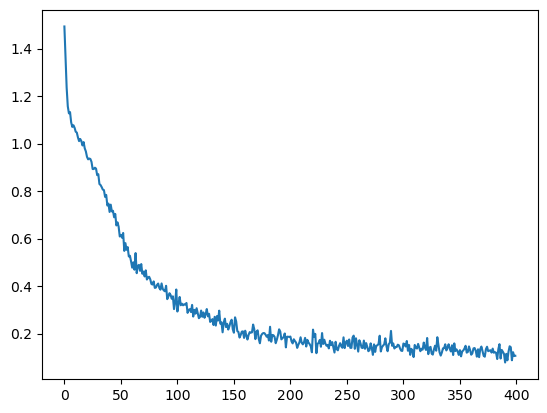

In [36]:
model = FullyConnected()
model.to('cuda:0')  # Move model to GPU
X_tr_tensor = X_tr_tensor.to('cuda:0')  # Move tensors to GPU
y_tr_tensor = y_tr_tensor.to('cuda:0')
fit(model)

In [37]:
X_ts_tensor = torch.tensor(X_test, dtype=torch.float32).to('cuda:0')
ytest_pred = model(X_ts_tensor)
newytest = torch.argmax(ytest_pred, dim=1)

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(newytest.cpu(), y_test))
print("Confusion Matrix:\n", confusion_matrix(newytest.cpu(), y_test))

Accuracy: 0.8
Confusion Matrix:
 [[ 5  4  0]
 [ 0  9  0]
 [ 0  2 10]]


In [71]:
## NN Regression example

In [47]:
import torch
import torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data[:,:3], iris.data[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)
print(X_train.shape)
X_tr_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_train, dtype=torch.float32)

(120, 3)


In [66]:
class FullyConnected(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(3, 64)  # Input layer to 64 neurons
        self.act1 = nn.ReLU()       # ReLU activation function
        self.l2 = nn.Linear(64, 16) # 64 neurons to 16 neurons
        self.drop = nn.Dropout(0.2) # Dropout for regularization
        self.act2 = nn.ReLU()       # Another ReLU
        self.l3 = nn.Linear(16, 1)  # Output layer to 3 neurons (classes)

    def forward(self, x):
        # Forward pass
        x = self.l1(x)
        x = self.act1(x)
        x = self.l2(x)
        x = self.drop(x)
        x = self.act2(x)
        x = self.l3(x)
        return x

In [67]:
def fit(model):
    epochs = 400
    loss_arr = []
    loss_fn = nn.MSELoss()
    optim = torch.optim.Adam(model.parameters(), lr=0.002)

    for epoch in range(epochs):
        ypred = model(X_tr_tensor)
        loss = loss_fn(ypred, y_tr_tensor)
        loss_arr.append(loss.item())
        loss.backward()
        optim.step()
        optim.zero_grad()
    plt.plot(loss_arr)
    plt.show()

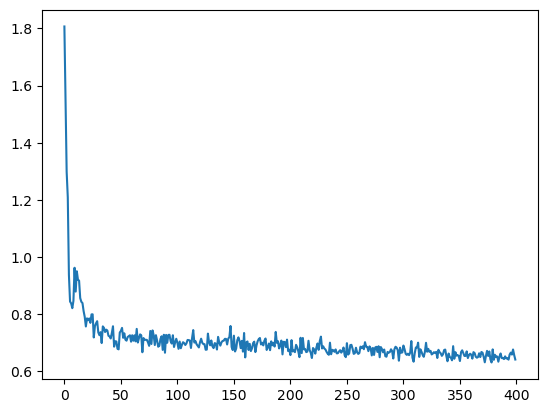

In [68]:
model = FullyConnected()
model.to('cuda:0')  # Move model to GPU
X_tr_tensor = X_tr_tensor.to('cuda:0')  # Move tensors to GPU
y_tr_tensor = y_tr_tensor.to('cuda:0')
fit(model)

In [69]:
X_ts_tensor = torch.tensor(X_test, dtype=torch.float32).to('cuda:0')
ytest_pred = model(X_ts_tensor)
ytest_pred.detach().cpu().numpy()

array([[1.1726784 ],
       [1.0511096 ],
       [1.3988276 ],
       [1.1095854 ],
       [0.7755115 ],
       [1.0689356 ],
       [1.4723291 ],
       [1.0217679 ],
       [1.0723478 ],
       [0.8065196 ],
       [1.3607495 ],
       [0.81585336],
       [1.1769259 ],
       [1.1546683 ],
       [1.0340737 ],
       [1.2898815 ],
       [1.1094556 ],
       [1.4944941 ],
       [1.4418087 ],
       [1.4581969 ],
       [1.030072  ],
       [1.0737913 ],
       [1.3630848 ],
       [1.2158293 ],
       [1.0222538 ],
       [1.117445  ],
       [0.9962579 ],
       [1.335046  ],
       [1.0111759 ],
       [1.4531543 ]], dtype=float32)

In [70]:
for ii in range (0, y_test.shape[0]):
    print("label:{} and pred:{}".format(y_test[ii], ytest_pred[ii]))

label:1.8 and pred:tensor([1.1727], device='cuda:0', grad_fn=<SelectBackward0>)
label:1.5 and pred:tensor([1.0511], device='cuda:0', grad_fn=<SelectBackward0>)
label:0.2 and pred:tensor([1.3988], device='cuda:0', grad_fn=<SelectBackward0>)
label:0.2 and pred:tensor([1.1096], device='cuda:0', grad_fn=<SelectBackward0>)
label:2.2 and pred:tensor([0.7755], device='cuda:0', grad_fn=<SelectBackward0>)
label:1.0 and pred:tensor([1.0689], device='cuda:0', grad_fn=<SelectBackward0>)
label:1.5 and pred:tensor([1.4723], device='cuda:0', grad_fn=<SelectBackward0>)
label:1.5 and pred:tensor([1.0218], device='cuda:0', grad_fn=<SelectBackward0>)
label:1.5 and pred:tensor([1.0723], device='cuda:0', grad_fn=<SelectBackward0>)
label:2.0 and pred:tensor([0.8065], device='cuda:0', grad_fn=<SelectBackward0>)
label:0.2 and pred:tensor([1.3607], device='cuda:0', grad_fn=<SelectBackward0>)
label:1.8 and pred:tensor([0.8159], device='cuda:0', grad_fn=<SelectBackward0>)
label:0.4 and pred:tensor([1.1769], devi